# Detectors and Results

The NSQ engine provides four detector types, each capturing a different aspect
of the radiation reaching a surface:

| Detector | Result class | Records |
|---|---|---|
| `IrradianceDetector` | `IrradianceMap` | 2D spatial flux map |
| `FarFieldDetector` | `FarFieldPattern` | Angular (θ, φ) intensity distribution |
| `SpectralDetector` | `SpectralResult` | Per-wavelength irradiance map |
| `RayDatabaseDetector` | `RayDatabase` | Full phase-space record (x, y, z, L, M, N, flux, λ) |

Multiple detectors can be active simultaneously in the same scene. Each is
accumulated independently during the trace.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    PointSourceConfig, CollimatedSourceConfig,
    IrradianceDetectorConfig, FarFieldDetectorConfig,
    SpectralDetectorConfig, RayDatabaseConfig,
    LensConfig,
)

spec_green  = Spectrum.monochromatic(0.55)
spec_rgb    = Spectrum(
    wavelengths=np.array([0.45, 0.55, 0.65]),
    weights=np.array([1.0, 1.5, 1.0]),
)

# The demo singlet used throughout this notebook: biconvex N-BK7, f = 49.1 mm.
# Its back focal distance from the rear vertex is 47.4 mm, so with the front
# vertex at z = 0 and 5 mm of centre thickness the paraxial focus sits at
# z = 52.4 mm. Every detector below goes there unless a cell is deliberately
# showing the beam away from focus.
DEMO_LENS = LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                       front_aperture_radius=12.5)
FOCUS_Z = 52.4


## 1. IrradianceDetector

The most common detector. Records total flux deposited in each pixel of a
rectangular grid. The result `IrradianceMap.irradiance` is in **W/mm²**.

Use `IrradianceDetectorConfig(width, height, num_pixels_x, num_pixels_y)` to
configure it.

IrradianceMap shape: (128, 128)
Peak irradiance    : 31.665 W/mm²
Total detected flux: 0.9173 W of 1.0 W launched
Rays on detector   : 183,468


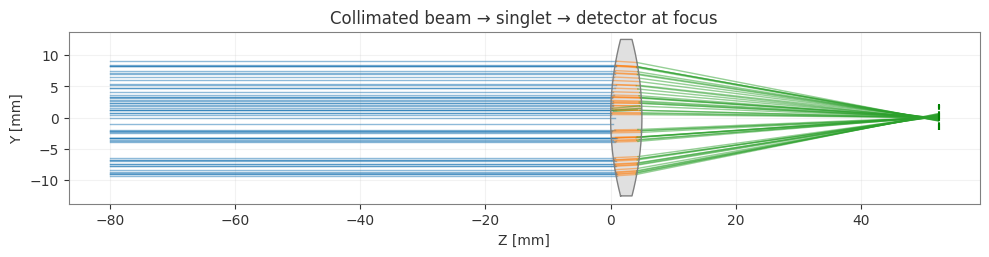

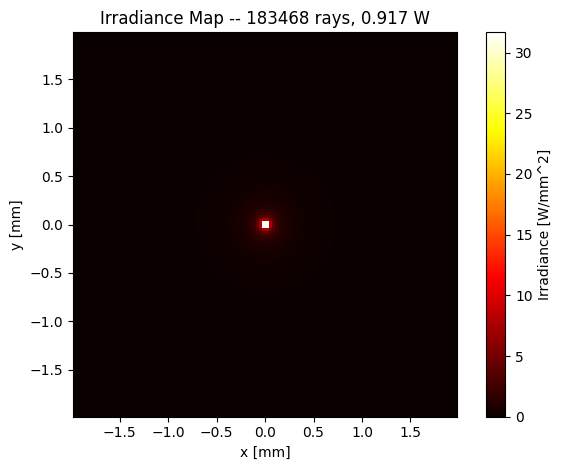

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene.add_detector(
    'D_irr', CoordinateSystem(z=FOCUS_Z),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=200_000, seed=42)
irr_map = result.detectors['D_irr']

print(f"IrradianceMap shape: {irr_map.irradiance.shape}")
print(f"Peak irradiance    : {irr_map.irradiance.max():.3f} W/mm\u00b2")
print(f"Total detected flux: {irr_map.total_flux:.4f} W of {result.total_flux_in:.1f} W launched")
print(f"Rays on detector   : {irr_map.num_rays_hit:,}")

# The scene that produced it. Rays are coloured by how many surfaces they have
# already crossed, so the incoming beam, the two glass legs and the converging
# cone are each a different colour.
scene.view(num_rays=60, color_by='bounce',
           title='Collimated beam \u2192 singlet \u2192 detector at focus')
plt.show()

fig = irr_map.plot(cmap='hot')
plt.tight_layout()
plt.show()
plt.close(fig)


## 2. FarFieldDetector

Records the **angular distribution** of radiation. Instead of spatial position,
it bins each ray by its direction (θ, φ) at the detector surface.

The result `FarFieldPattern.intensity` is in **W/sr** and has shape
`(num_bins_theta, num_bins_phi)`. Note that `intensity` is per unit solid
angle, so summing it does *not* give a flux; use `FarFieldPattern.total_flux`
(in W) for the radiometric total.

The detector is placed at a finite location but uses a very large aperture
(1 km radius by default) so it captures essentially all forward-going rays.

FarFieldPattern shape: (45, 180)  (theta x phi)
Total flux recorded  : 0.9998 W
Peak intensity       : 1.88 W/sr


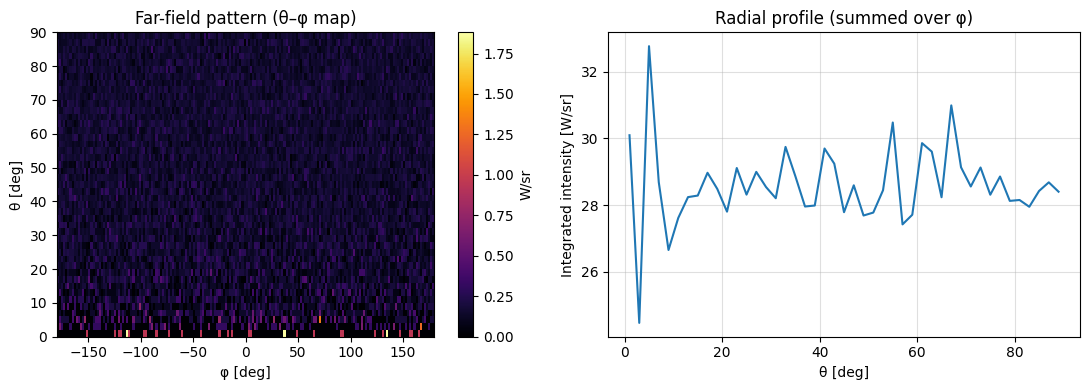

In [3]:
scene_ff = NSQScene()
# Isotropic hemisphere point source
scene_ff.add_source(
    'S', CoordinateSystem(z=0),
    PointSourceConfig(spectrum=spec_green, total_flux=1.0, half_angle_deg=90),
)
# FarFieldDetector captures the hemisphere at z > 0
scene_ff.add_detector(
    'FF', CoordinateSystem(z=100),
    FarFieldDetectorConfig(num_theta=45, num_phi=180),
)

result_ff = scene_ff.trace(num_rays=50_000, seed=42)
ff = result_ff.detectors['FF']

print(f"FarFieldPattern shape: {ff.intensity.shape}  (theta x phi)")
print(f"Total flux recorded  : {ff.total_flux:.4f} W")
print(f"Peak intensity       : {ff.intensity.max():.2f} W/sr")

# Sum over phi to get radial profile
intensity_radial = ff.intensity.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].pcolormesh(ff.phi, ff.theta, ff.intensity, cmap='inferno', shading='auto')
plt.colorbar(im, ax=axes[0], label='W/sr')
axes[0].set_xlabel('φ [deg]'); axes[0].set_ylabel('θ [deg]')
axes[0].set_title('Far-field pattern (θ–φ map)')

axes[1].plot(ff.theta, intensity_radial)
axes[1].set_xlabel('θ [deg]'); axes[1].set_ylabel('Integrated intensity [W/sr]')
axes[1].set_title('Radial profile (summed over φ)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

## 3. SpectralDetector

Extends the irradiance detector with a third wavelength dimension. The result
`SpectralResult.irradiance` has shape `(ny, nx, n_lambda)` in W/mm², holding the
flux that landed in each wavelength bin (it is binned, not divided by bin width,
so summing over the last axis recovers the broadband irradiance).

Add a `SpectralDetector` via `SpectralDetectorConfig`. Its binning range
(`wl_min`, `wl_max`) is given in **micrometres**, the same unit `Spectrum` uses
and the same unit as every other wavelength in Optiland — the visible band is
`wl_min=0.4, wl_max=0.7`.

This is where a spectral detector earns its keep: N-BK7 is dispersive, so the
three source lines do not share a focus. A higher index means a shorter focal
length, so blue focuses nearest the lens and red furthest from it; over
0.45–0.65 µm the index falls by about 0.011, spreading the focus over roughly
1 mm.

The detector sits at z = 52.4, the *paraxial* 0.55 µm focus. Spherical
aberration in this f/2.45 singlet pulls the real green focus in to about
z = 50, so at this plane it is red that happens to be nearest its own focus and
blue that is furthest past it. That ordering is not obvious from the maps, which
is the point of measuring rather than eyeballing — the per-bin peak irradiance
printed below says it outright.


SpectralResult irradiance shape: (64, 64, 30)  (ny, nx, nlambda)
Occupied bins: [5, 15, 25]
  bin  5  centre 0.455 µm  0.2615 W
  bin 15  centre 0.555 µm  0.3935 W
  bin 25  centre 0.655 µm  0.2612 W
Sum over bins: 0.9162 W  (= total_flux 0.9162 W)

Peak irradiance per bin. Normalising by the flux in each bin removes
the 1 : 1.5 : 1 source weighting, leaving only how tightly each line
is focused at this one plane:
  0.455 µm:     1.90 W/mm² (7.3 per watt in the bin)
  0.555 µm:     5.62 W/mm² (14.3 per watt in the bin)
  0.655 µm:     5.20 W/mm² (19.9 per watt in the bin)


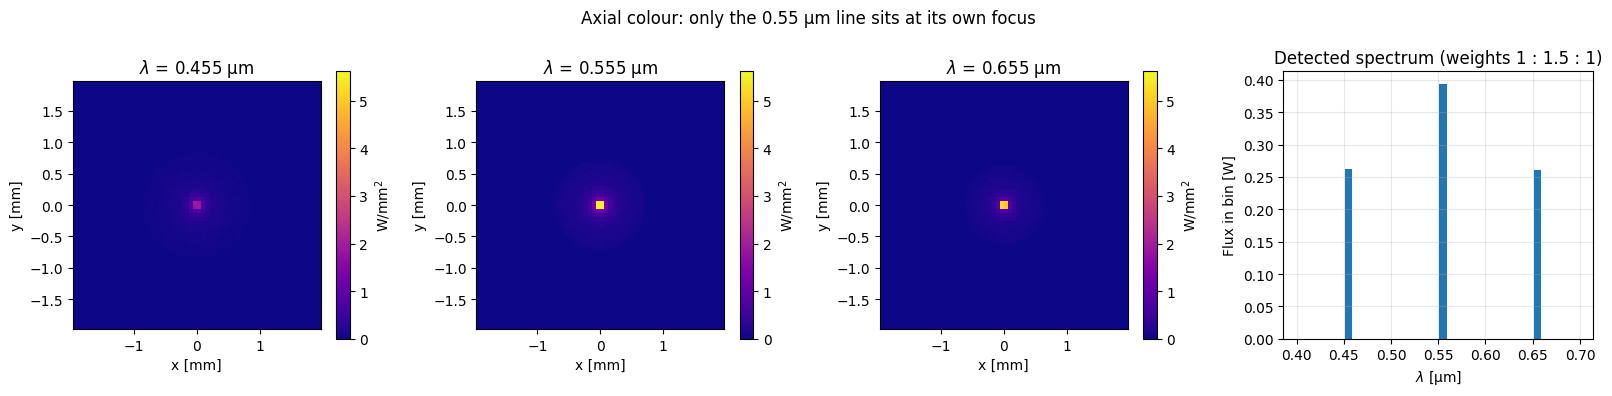

In [4]:
scene_sp = NSQScene()
scene_sp.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_rgb, total_flux=1.0, aperture_radius=10.0),
)
scene_sp.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_sp.add_detector(
    'SD', CoordinateSystem(z=FOCUS_Z),
    SpectralDetectorConfig(width=4, height=4, num_pixels_x=64, num_pixels_y=64,
                           wl_min=0.4, wl_max=0.7, num_bins=30),
)

result_sp = scene_sp.trace(num_rays=200_000, seed=42)
sp_result = result_sp.detectors['SD']

pixel_area = (4 / 64) ** 2
flux_per_bin = sp_result.irradiance.sum(axis=(0, 1)) * pixel_area
occupied = np.flatnonzero(flux_per_bin)

print(f"SpectralResult irradiance shape: {sp_result.irradiance.shape}  (ny, nx, nlambda)")
print(f"Occupied bins: {occupied.tolist()}")
for i in occupied:
    print(f"  bin {i:2d}  centre {sp_result.wavelengths[i]:.3f} \u00b5m  "
          f"{flux_per_bin[i]:.4f} W")
print(f"Sum over bins: {flux_per_bin.sum():.4f} W  "
      f"(= total_flux {sp_result.total_flux:.4f} W)")
print("\nPeak irradiance per bin. Normalising by the flux in each bin removes"
      "\nthe 1 : 1.5 : 1 source weighting, leaving only how tightly each line"
      "\nis focused at this one plane:")
for i in occupied:
    peak = sp_result.irradiance[:, :, i].max()
    print(f"  {sp_result.wavelengths[i]:.3f} \u00b5m: {peak:8.2f} W/mm\u00b2 "
          f"({peak / flux_per_bin[i]:.1f} per watt in the bin)")

# Irradiance map in each occupied bin, on a shared colour scale so the
# wavelengths are directly comparable.
maps = [sp_result.irradiance[:, :, i] for i in occupied]
vmax = max(m.max() for m in maps)
extent = [sp_result.x_coords[0], sp_result.x_coords[-1],
          sp_result.y_coords[0], sp_result.y_coords[-1]]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, E_wl in zip(axes, occupied, maps):
    im = ax.imshow(E_wl, origin='lower', cmap='plasma', aspect='equal',
                   extent=extent, vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'$\\lambda$ = {sp_result.wavelengths[i]:.3f} \u00b5m')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')

axes[3].bar(sp_result.wavelengths, flux_per_bin, width=0.008)
axes[3].set_xlabel('$\\lambda$ [\u00b5m]'); axes[3].set_ylabel('Flux in bin [W]')
axes[3].set_title('Detected spectrum (weights 1 : 1.5 : 1)')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Axial colour: only the 0.55 \u00b5m line sits at its own focus',
             fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)


## 4. RayDatabaseDetector

Stores complete phase-space information for every ray that hits the detector:
position (x, y, z), direction cosines (L, M, N), flux, and wavelength. This
enables post-trace analysis beyond what the other detectors support.

The `RayDatabase.to_dataframe()` method converts the data to a pandas DataFrame
for convenient analysis.

Rays stored: 45,892
Total flux : 0.9178 W


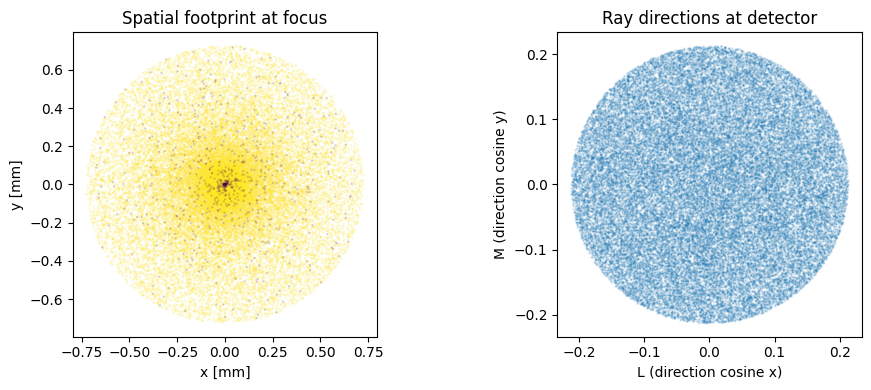

In [5]:
scene_rdb = NSQScene()
scene_rdb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_rdb.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_rdb.add_detector(
    'RDB', CoordinateSystem(z=FOCUS_Z),
    RayDatabaseConfig(width=4, height=4),
)

result_rdb = scene_rdb.trace(num_rays=50_000, seed=42)
db = result_rdb.detectors['RDB']

print(f"Rays stored: {db.num_rays:,}")
print(f"Total flux : {db.flux.sum():.4f} W")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(db.x, db.y, s=0.5, alpha=0.15, c=db.flux, cmap='viridis')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')
axes[0].set_title('Spatial footprint at focus')
axes[0].set_aspect('equal')

# Direction cosines: the converging cone maps to a filled disk whose radius is
# set by the marginal ray angle, i.e. by the f-number.
axes[1].scatter(db.L, db.M, s=0.5, alpha=0.15)
axes[1].set_xlabel('L (direction cosine x)'); axes[1].set_ylabel('M (direction cosine y)')
axes[1].set_title('Ray directions at detector')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
plt.close(fig)


## 5. Multiple Detectors in One Scene

Detectors are **absorbing**: a ray that reaches one is recorded and then
terminated. Several detectors can share a scene, and each accumulates
independently, but only the first detector along a given ray's path ever sees
that ray.

That makes stacking detectors down a single beam the one thing detectors cannot
do — the nearest plane would record everything and the rest would come back
empty. Where multiple detectors do pay off is when they intercept *different*
rays: a forward and a backward detector around a lens, a receiver plus a spill
monitor, or one detector per output port of a splitter.


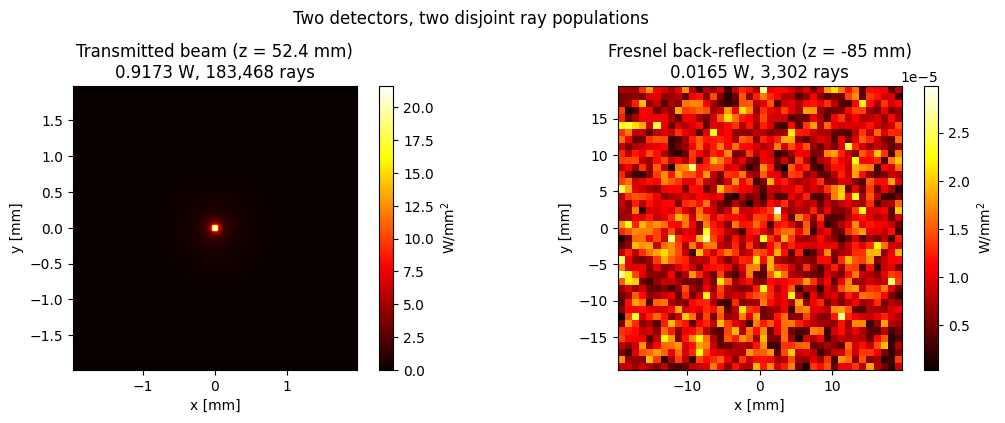

Forward : 0.9173 W
Backward: 0.0165 W
Escaped : 0.0662 W


In [6]:
# Forward and backward detectors catch disjoint populations: the transmitted
# beam, and the Fresnel reflection travelling back towards the source.
scene_fb = NSQScene()
scene_fb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=10.0),
)
scene_fb.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
scene_fb.add_detector(
    'D_fwd', CoordinateSystem(z=FOCUS_Z),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=96, num_pixels_y=96),
)
# Coarse bins: the back-reflection carries ~2% of the flux, so fine pixels
# would show mostly shot noise.
scene_fb.add_detector(
    'D_back', CoordinateSystem(z=-85),
    IrradianceDetectorConfig(width=40, height=40, num_pixels_x=40, num_pixels_y=40),
)

result_fb = scene_fb.trace(num_rays=200_000, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, name, label in zip(axes, ['D_fwd', 'D_back'],
                           ['Transmitted beam (z = 52.4 mm)',
                            'Fresnel back-reflection (z = -85 mm)']):
    irr = result_fb.detectors[name]
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    ax.set_title(f'{label}\n{irr.total_flux:.4f} W, {irr.num_rays_hit:,} rays')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Two detectors, two disjoint ray populations', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Forward : {result_fb.detectors['D_fwd'].total_flux:.4f} W")
print(f"Backward: {result_fb.detectors['D_back'].total_flux:.4f} W")
print(f"Escaped : {result_fb.total_flux_escaped:.4f} W")


### Profiling a beam at several planes

Because detectors absorb, a caustic scan is one trace per plane. The loop below
walks a single detector through focus:


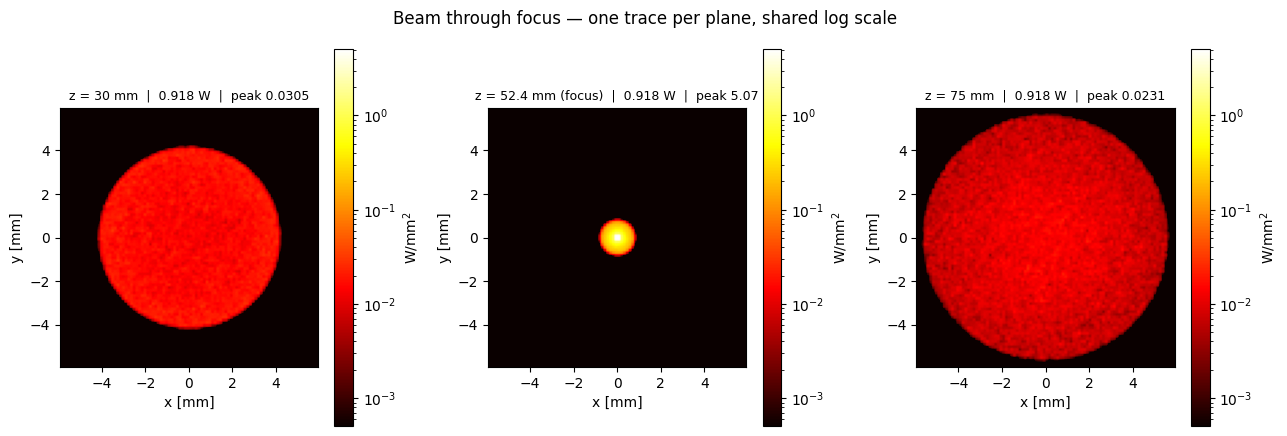

In [7]:
def beam_at(z, half_width=12.0, n_rays=60_000):
    """Trace the demo scene with a single detector at plane z."""
    s = NSQScene()
    s.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0,
                               aperture_radius=10.0),
    )
    s.add_lens('L', CoordinateSystem(z=0), DEMO_LENS)
    s.add_detector(
        'D', CoordinateSystem(z=z),
        IrradianceDetectorConfig(width=half_width, height=half_width,
                                 num_pixels_x=96, num_pixels_y=96),
    )
    return s.trace(num_rays=n_rays, seed=42).detectors['D']


planes = [30.0, FOCUS_Z, 75.0]
maps = [beam_at(z) for z in planes]
vmax = max(m.irradiance.max() for m in maps)

# The focus is some 500x brighter than the planes either side of it, so a
# linear shared scale renders those two solid black. A shared log scale keeps
# the comparison honest and still shows the caustic.
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=vmax * 1e-4, vmax=vmax)

# LogNorm masks the empty pixels rather than colouring them; paint them the
# floor colour so the unlit area reads as background instead of speckle.
cmap = plt.get_cmap('hot').copy()
cmap.set_bad(cmap(0.0))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, z, irr in zip(axes, planes, maps):
    im = ax.imshow(irr.irradiance, origin='lower', cmap=cmap, aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                           irr.y_coords[0], irr.y_coords[-1]],
                   norm=norm)
    plt.colorbar(im, ax=ax, label='W/mm$^2$')
    tag = ' (focus)' if abs(z - FOCUS_Z) < 1e-6 else ''
    ax.set_title(f'z = {z:g} mm{tag}  |  {irr.total_flux:.3f} W  |  '
                 f'peak {irr.irradiance.max():.3g}', fontsize=9)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Beam through focus \u2014 one trace per plane, shared log scale',
             fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)


## Summary

- `IrradianceDetector` → `IrradianceMap`: 2D flux map, `irradiance` in W/mm²
- `FarFieldDetector` → `FarFieldPattern`: angular distribution, `intensity` in W/sr
- `SpectralDetector` → `SpectralResult`: per-wavelength 2D map; the binning range
  (`wl_min`/`wl_max`/`num_bins`) is in **µm**, like every other wavelength in Optiland
- `RayDatabaseDetector` → `RayDatabase`: full phase-space record; use `.to_dataframe()`
  for analysis
- Detectors **absorb**: only the first detector along a ray's path records it. Use
  several detectors to catch different ray populations, and one trace per plane to
  profile a single beam along its length
- Put the detector where the light actually goes. This lens has f = 49.1 mm and a
  47.4 mm back focal distance, so the focus is at z = 52.4 mm; a detector at z = 100
  would measure a 7.5 mm defocus blur, not a spot
